# FixtureIQ - Model Analysis & Injury Data Integration

**Purpose**: Explore all available data across 3 seasons, compare proxy vs injury-target models, and identify improvements.

**Data sources**: SofaScore dynamic master CSVs (2022-23 through 2024-25), injury records, ClubElo, Understat

## 1. Setup & Imports

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, 
    precision_recall_curve, roc_curve, classification_report, confusion_matrix)
import xgboost as xgb

_root = Path('..').resolve()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.config.paths import data_dir, model_dir, results_dir
from src.features.engineering import engineer_features, TEAM_NAME_MAP, UCL_TEAMS_BY_SEASON, SEASON_MAP
from src.features.target import define_target, load_injury_data, merge_injury_target

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Setup complete')

Setup complete


## 2. Load All Master CSVs (3 Seasons)

In [2]:
SEASONS = ['2022-2023', '2023-2024', '2024-2025']
SEASON_KEYS = {'2022-2023': '2022_2023', '2023-2024': '2023_2024', '2024-2025': '2024_2025'}

all_frames = []
for s in SEASONS:
    path = data_dir() / s / 'sofascore_dynamic' / 'fixtureiq_dynamic_master.csv'
    df = pd.read_csv(path, low_memory=False)
    df['season_tag'] = s
    df['season_key'] = SEASON_KEYS[s]
    df['season'] = df['season_key']
    all_frames.append(df)
    print(f'{s}: {len(df):>6} rows, {df["name"].nunique():>4} players, {df["teamName"].nunique():>2} teams')

df_raw = pd.concat(all_frames, ignore_index=True, sort=False)
print(f'Total: {len(df_raw):,} rows, {df_raw["name"].nunique():,} unique players')

2022-2023:   7304 rows, 1020 players, 36 teams
2023-2024:  14758 rows, 1062 players, 34 teams
2024-2025:   7587 rows, 1182 players, 43 teams
Total: 29,649 rows, 2,071 unique players


### 2.1 Column alignment across seasons

In [3]:
for s in SEASONS:
    path = data_dir() / s / 'sofascore_dynamic' / 'fixtureiq_dynamic_master.csv'
    cols = set(pd.read_csv(path, nrows=1).columns)
    print(f'{s}: {len(cols)} columns')

common = set(df_raw.columns)
print(f'Union of all columns: {len(common)}')

2022-2023: 108 columns
2023-2024: 106 columns
2024-2025: 117 columns
Union of all columns: 122


## 3. Injury Data Exploration

In [4]:
inj = load_injury_data(data_dir())
print(f'Total injury records: {len(inj):,}')
print(f'Genuine injuries:     {inj["is_injury"].sum():,} ({inj["is_injury"].mean()*100:.1f}%)')
print(f'Non-injury reasons:   {(~inj["is_injury"]).sum():,}')
print(f'Unique players:       {inj["player_name"].nunique():,}')
print(f'Unique teams:         {inj["team_name"].nunique():,}')
print(f'Date range:           {inj["fixture_date"].min()} to {inj["fixture_date"].max()}')

Total injury records: 9,526
Genuine injuries:     8,360 (87.8%)
Non-injury reasons:   1,166
Unique players:       709
Unique teams:         24
Date range:           2022-08-05 00:00:00 to 2025-05-25 00:00:00


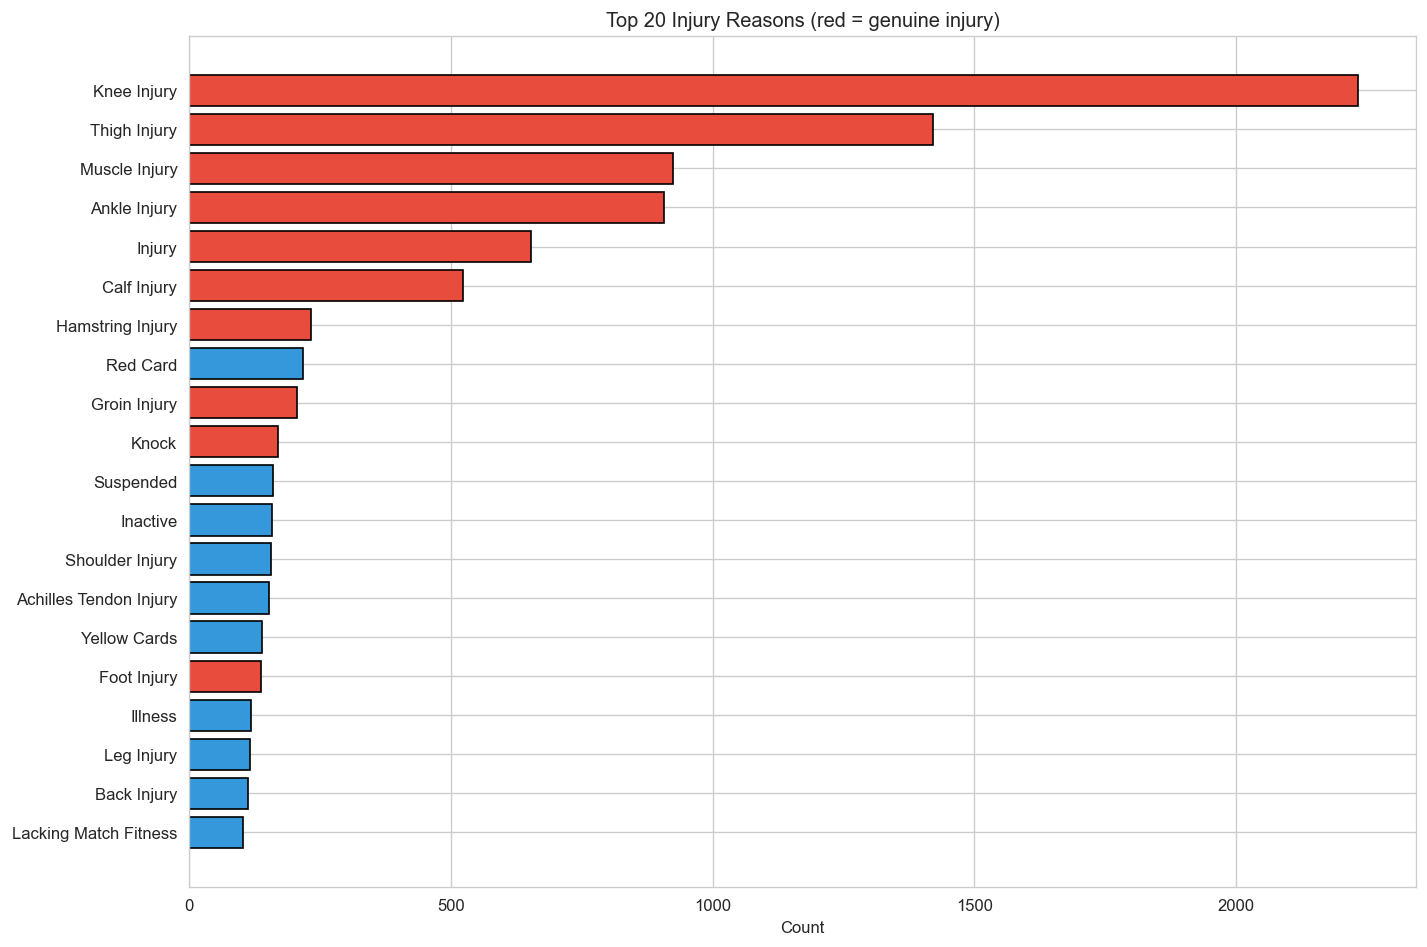

In [5]:
reason_counts = inj['reason'].value_counts()
fig, ax = plt.subplots(figsize=(12, 8))
genuine_set = {'Injury','Knock','Hamstring Injury','Knee Injury',
               'Ankle Injury','Thigh Injury','Calf Injury','Groin Injury',
               'Muscle Injury','Foot Injury'}
colors = ['#E74C3C' if r in genuine_set else '#3498DB' 
          for r in reason_counts.index[:20]]
ax.barh(range(len(reason_counts[:20])), reason_counts[:20].values, color=colors, edgecolor='black')
ax.set_yticks(range(len(reason_counts[:20])))
ax.set_yticklabels(reason_counts[:20].index)
ax.set_xlabel('Count')
ax.set_title('Top 20 Injury Reasons (red = genuine injury)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

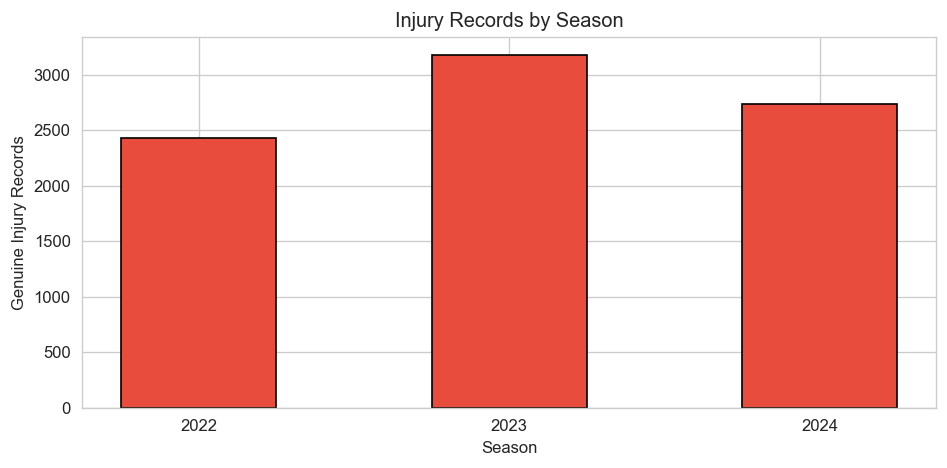

In [6]:
inj['season_year'] = inj['season'].str[:4]
season_counts = inj[inj['is_injury']].groupby('season_year').size()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(season_counts.index, season_counts.values, color='#E74C3C', edgecolor='black', width=0.5)
ax.set_xlabel('Season')
ax.set_ylabel('Genuine Injury Records')
ax.set_title('Injury Records by Season')
plt.tight_layout()
plt.show()

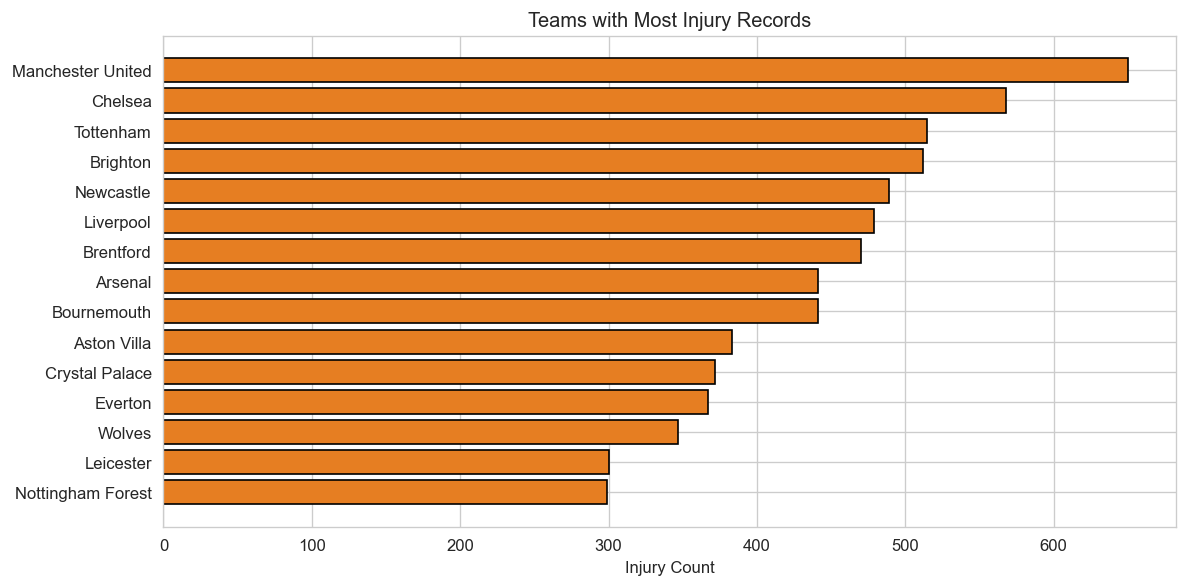

In [7]:
team_inj = inj[inj['is_injury']]['team_name'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(team_inj)), team_inj.values, color='#E67E22', edgecolor='black')
ax.set_yticks(range(len(team_inj)))
ax.set_yticklabels(team_inj.index)
ax.set_xlabel('Injury Count')
ax.set_title('Teams with Most Injury Records')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

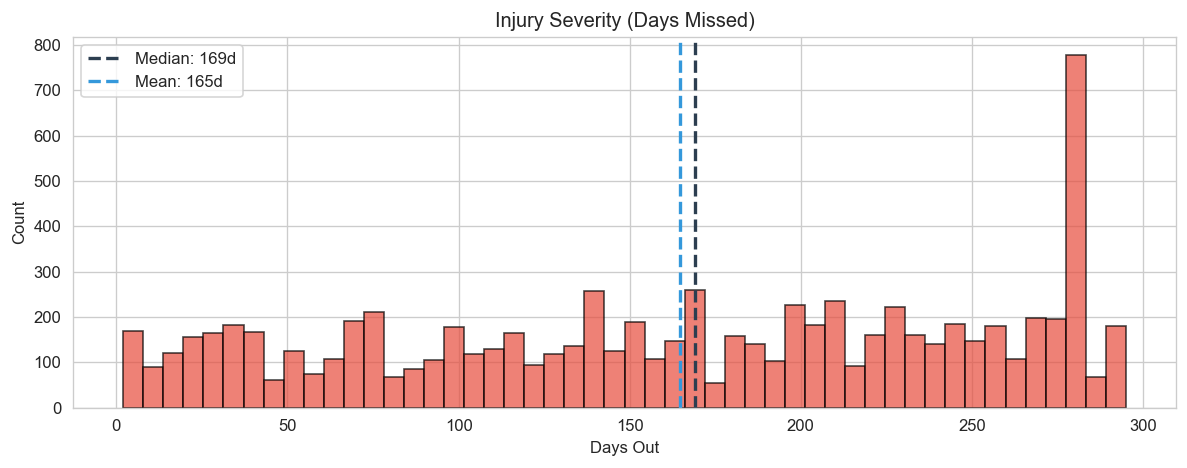

Injury duration stats:
  Mean: 164.7d, Median: 169d
  25th: 91d, 75th: 245d


In [8]:
days = inj[inj['is_injury'] & (inj['days_out'] > 0) & (inj['days_out'] < 365)]['days_out']
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(days, bins=50, color='#E74C3C', edgecolor='black', alpha=0.7)
ax.axvline(days.median(), color='#2C3E50', ls='--', lw=2, label=f'Median: {days.median():.0f}d')
ax.axvline(days.mean(), color='#3498DB', ls='--', lw=2, label=f'Mean: {days.mean():.0f}d')
ax.set_xlabel('Days Out')
ax.set_ylabel('Count')
ax.set_title('Injury Severity (Days Missed)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Injury duration stats:')
print(f'  Mean: {days.mean():.1f}d, Median: {days.median():.0f}d')
print(f'  25th: {days.quantile(0.25):.0f}d, 75th: {days.quantile(0.75):.0f}d')

## 4. Feature Engineering Pipeline

In [9]:
for df in all_frames:
    if 'match_date_str' not in df.columns and 'date' in df.columns:
        df.rename(columns={'date': 'match_date_str'}, inplace=True)
    df['match_date'] = pd.to_datetime(df['match_date_str'])
    df['source'] = 'sofascore_dynamic'

df_all = pd.concat(all_frames, ignore_index=True, sort=False)
df_all['team_name'] = df_all['teamName'].map(TEAM_NAME_MAP).fillna(df_all['teamName'])
print(f'Raw: {len(df_all):,} rows')

df_feat = engineer_features(df_all)
new_cols = [c for c in df_feat.columns if c not in df_all.columns]
print(f'After engineering: {len(df_feat):,} rows')
print(f'New features: {new_cols}')

Raw: 29,649 rows
After engineering: 29,649 rows
New features: ['season_ordinal', 'is_ucl_team', 'is_non_ucl_team', 'position_code', 'rating_rolling_avg_5', 'rating_rolling_std_5', 'min_last_3', 'is_ucl_match', 'is_pl_match', 'is_cup_match']


In [10]:
df_feat = merge_injury_target(df_feat, inj, window_days=14)
print(f'Injury flag rate: {df_feat["injury_flag"].mean()*100:.2f}%')
print(f'Players with injuries: {df_feat[df_feat["injury_flag"]==1]["name"].nunique()}')

df_feat = define_target(df_feat)
print(f'Fatigue risk rate: {df_feat["fatigue_risk"].mean()*100:.1f}%')

cross = pd.crosstab(df_feat['fatigue_risk'], df_feat['injury_flag'], margins=True)
print('Proxy vs Injury cross-tabulation:')
print(cross)

Injury flag rate: 1.70%
Players with injuries: 179
Fatigue risk rate: 11.4%
Proxy vs Injury cross-tabulation:
injury_flag       0    1    All
fatigue_risk                   
0             25836  434  26270
1              3309   70   3379
All           29145  504  29649


## 5. Model Training Comparison

In [11]:
CORE_FEATURES = [
    'rest_days', 'high_congestion_flag', 'min_last_7d', 'acwr_ratio',
    'minutesPlayed', 'consecutive_away_games', 'lineup_churn',
    'is_away', 'position_code', 'season_ordinal',
]
PERF_FEATURES = [
    'rating', 'totalPass', 'accuratePass', 'totalTackle', 'wonTackle',
    'duelWon', 'duelLost', 'aerialWon', 'aerialLost',
    'expectedGoals', 'expectedAssists', 'keyPass',
    'totalShots', 'onTargetScoringAttempt', 'fouls', 'wasFouled',
    'touches', 'dispossessed', 'bigChanceCreated',
]
CONTEXT_FEATURES = [
    'elo', 'team_xg', 'team_xga', 'is_ucl_match', 'is_pl_match', 'is_ucl_team',
]

feature_cols = CORE_FEATURES + PERF_FEATURES + CONTEXT_FEATURES
available = [c for c in feature_cols if c in df_feat.columns]
missing = set(feature_cols) - set(available)
print(f'Available features: {len(available)}/{len(feature_cols)}')
if missing:
    print(f'Missing: {sorted(missing)}')

X = df_feat[available].fillna(0)
y_injury = df_feat['injury_flag'].values
y_proxy = df_feat['fatigue_risk'].values
print(f'Model matrix: {X.shape}')

Available features: 35/35
Model matrix: (29649, 35)


In [12]:
def train_and_eval(X, y, target_name, feature_names):
    print()
    print('=' * 60)
    print(f'Training: {target_name} (pos rate: {y.mean()*100:.2f}%)')
    
    scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)
    n_train = int(len(X) * 0.65)
    n_val = int(len(X) * 0.15)
    
    X_train, y_train = X.iloc[:n_train], y[:n_train]
    X_val, y_val = X.iloc[n_train:n_train+n_val], y[n_train:n_train+n_val]
    X_test, y_test = X.iloc[n_train+n_val:], y[n_train+n_val:]
    
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_va_s = scaler.transform(X_val)
    X_te_s = scaler.transform(X_test)
    
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='aucpr', early_stopping_rounds=30,
        random_state=42, verbosity=0,
    )
    model.fit(X_tr_s, y_train, eval_set=[(X_va_s, y_val)], verbose=False)
    
    y_pred = model.predict_proba(X_te_s)[:, 1]
    
    auc_roc = roc_auc_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_pred)
    
    print(f'  AUC-ROC: {auc_roc:.4f}')
    print(f'  AUC-PR:  {auc_pr:.4f}  (baseline: {y_test.mean():.4f})')
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    
    y_pred_bin = (y_pred >= best_threshold).astype(int)
    print(f'  Best threshold: {best_threshold:.3f}')
    print(f'  F1: {f1_scores[best_idx]:.4f}, Prec: {precisions[best_idx]:.4f}, Rec: {recalls[best_idx]:.4f}')
    print()
    print(classification_report(y_test, y_pred_bin, target_names=['Low Risk', target_name]))
    
    return model, scaler, y_test, y_pred, best_threshold

model_inj, scaler_inj, y_test_inj, y_pred_inj, thresh_inj = train_and_eval(
    X, y_injury, 'Injury Risk', available)
model_proxy, scaler_proxy, y_test_proxy, y_pred_proxy, thresh_proxy = train_and_eval(
    X, y_proxy, 'Fatigue Risk', available)


Training: Injury Risk (pos rate: 1.70%)
  AUC-ROC: 0.7067
  AUC-PR:  0.0387  (baseline: 0.0165)
  Best threshold: 0.558
  F1: 0.0884, Prec: 0.0557, Rec: 0.2143

              precision    recall  f1-score   support

    Low Risk       0.99      0.94      0.96      5833
 Injury Risk       0.06      0.21      0.09        98

    accuracy                           0.93      5931
   macro avg       0.52      0.58      0.53      5931
weighted avg       0.97      0.93      0.95      5931


Training: Fatigue Risk (pos rate: 11.40%)
  AUC-ROC: 0.9841
  AUC-PR:  0.9597  (baseline: 0.1120)
  Best threshold: 0.565
  F1: 0.9384, Prec: 0.9725, Rec: 0.9066

              precision    recall  f1-score   support

    Low Risk       0.99      1.00      0.99      5267
Fatigue Risk       0.97      0.91      0.94       664

    accuracy                           0.99      5931
   macro avg       0.98      0.95      0.97      5931
weighted avg       0.99      0.99      0.99      5931



### 5.1 ROC & PR Curves Comparison

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fpr_i, tpr_i, _ = roc_curve(y_test_inj, y_pred_inj)
fpr_p, tpr_p, _ = roc_curve(y_test_proxy, y_pred_proxy)
auc_i = roc_auc_score(y_test_inj, y_pred_inj)
auc_p = roc_auc_score(y_test_proxy, y_pred_proxy)

ax1.plot(fpr_i, tpr_i, lw=2, label=f'Injury target (AUC={auc_i:.3f})', color='#E74C3C')
ax1.plot(fpr_p, tpr_p, lw=2, label=f'Proxy target (AUC={auc_p:.3f})', color='#3498DB')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

prec_i, rec_i, _ = precision_recall_curve(y_test_inj, y_pred_inj)
prec_p, rec_p, _ = precision_recall_curve(y_test_proxy, y_pred_proxy)
ap_i = average_precision_score(y_test_inj, y_pred_inj)
ap_p = average_precision_score(y_test_proxy, y_pred_proxy)

ax2.plot(rec_i, prec_i, lw=2, label=f'Injury target (AP={ap_i:.3f})', color='#E74C3C')
ax2.plot(rec_p, prec_p, lw=2, label=f'Proxy target (AP={ap_p:.3f})', color='#3498DB')
ax2.axhline(y_test_inj.mean(), color='#E74C3C', ls='--', alpha=0.3, label=f'Injury baseline ({y_test_inj.mean():.3f})')
ax2.axhline(y_test_proxy.mean(), color='#3498DB', ls='--', alpha=0.3, label=f'Proxy baseline ({y_test_proxy.mean():.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Feature Importance (Injury Model)

In [ ]:
importance = model_inj.feature_importances_
idx = np.argsort(importance)[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(idx)))
ax.barh(range(len(idx)), importance[idx], color=colors[::-1], edgecolor='black')
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([available[i] for i in idx])
ax.set_xlabel('Importance (gain)')
ax.set_title('Feature Importance - Injury Target Model')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.3 Feature Importance (Proxy Model)

In [ ]:
importance = model_proxy.feature_importances_
idx = np.argsort(importance)[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(idx)))
ax.barh(range(len(idx)), importance[idx], color=colors[::-1], edgecolor='black')
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([available[i] for i in idx])
ax.set_xlabel('Importance (gain)')
ax.set_title('Feature Importance - Proxy Target Model')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Cohort Analysis

In [ ]:
df_feat['position_group'] = df_feat['position'].map({
    'G': 'Goalkeeper', 'D': 'Defender', 'M': 'Midfielder', 'F': 'Forward',
    'GK': 'Goalkeeper', 'DF': 'Defender', 'MF': 'Midfielder', 'FW': 'Forward',
}).fillna('Unknown')

pos_inj = df_feat.groupby('position_group')['injury_flag'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print('Injury rate by position:')
print(pos_inj)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
colors_map = {'Goalkeeper': '#2ECC71', 'Defender': '#3498DB', 'Midfielder': '#F1C40F', 'Forward': '#E74C3C'}
for i, (pos, row) in enumerate(pos_inj.iterrows()):
    ax.bar(i, row['mean']*100, color=colors_map.get(pos, '#95A5A6'), edgecolor='black', width=0.5)
    ax.text(i, row['mean']*100 + 0.05, f'{row["mean"]*100:.2f}%\n(n={row["count"]:,.0f})', ha='center', fontsize=9)
ax.set_xticks(range(len(pos_inj)))
ax.set_xticklabels(pos_inj.index)
ax.set_ylabel('Injury Rate (%)')
ax.set_title('Injury Rate by Position')
plt.tight_layout()
plt.show()

In [ ]:
pos_both = df_feat.groupby('position_group')[['fatigue_risk', 'injury_flag']].mean() * 100
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(pos_both))
w = 0.35
ax.bar([i - w/2 for i in x], pos_both['fatigue_risk'], w, label='Fatigue Risk (proxy)', color='#3498DB', edgecolor='black')
ax.bar([i + w/2 for i in x], pos_both['injury_flag'], w, label='Injury Rate (ground truth)', color='#E74C3C', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(pos_both.index)
ax.set_ylabel('Rate (%)')
ax.set_title('Proxy vs Ground Truth by Position')
ax.legend()
plt.tight_layout()
plt.show()

### 6.1 UCL vs Non-UCL Analysis (2024-25 only)

In [ ]:
ucl_teams_2425 = {'Arsenal', 'Aston Villa', 'Liverpool', 'Manchester City'}
df_2425 = df_feat[df_feat['season'] == '2024_2025'].copy()
df_2425['is_ucl'] = df_2425['team_name'].isin(ucl_teams_2425)

ucl_stats = df_2425.groupby('is_ucl')[['fatigue_risk', 'injury_flag', 'rest_days', 'acwr_ratio', 'min_last_7d']].mean()
ucl_stats.columns = ['Fatigue Risk', 'Injury Rate', 'Rest Days', 'ACWR', 'Min Last 7d']
print('UCL vs Non-UCL (2024-25 only):')
print(ucl_stats.round(3))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['rest_days', 'acwr_ratio', 'min_last_7d']
titles = ['Rest Days', 'ACWR Ratio', 'Minutes Last 7 Days']
for i, (m, t) in enumerate(zip(metrics, titles)):
    ucl_val = df_2425[df_2425['is_ucl']][m].dropna()
    non_val = df_2425[~df_2425['is_ucl']][m].dropna()
    axes[i].hist(ucl_val, bins=30, alpha=0.6, label='UCL', color='#E74C3C', density=True)
    axes[i].hist(non_val, bins=30, alpha=0.6, label='Non-UCL', color='#3498DB', density=True)
    axes[i].axvline(ucl_val.median(), color='#E74C3C', ls='--', lw=2)
    axes[i].axvline(non_val.median(), color='#3498DB', ls='--', lw=2)
    axes[i].set_xlabel(t)
    axes[i].set_ylabel('Density')
    axes[i].set_title(t)
    axes[i].legend()
plt.tight_layout()
plt.show()

## 7. Name Matching Quality Check

In [ ]:
matched_players = set(df_feat[df_feat['injury_flag'] == 1]['name'].unique())
master_last_names = set(df_feat['name'].str.split().str[-1].str.lower())
injury_last_names = set(inj[inj['is_injury']]['player_name'].str.split().str[-1].str.lower())
unmatched = injury_last_names - master_last_names

print(f'Players flagged as injured in dataset: {len(matched_players)}')
print(f'Unique last names in injury data:      {len(injury_last_names)}')
print(f'Unique last names in master data:      {len(master_last_names)}')
print(f'Injury last names NOT in master data:  {len(unmatched)}')
if unmatched:
    print('  Examples:', sorted(list(unmatched))[:15])

## 8. Threshold Analysis for Injury Model

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test_inj, y_pred_inj)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(thresholds, f1_scores, lw=2, color='#9B59B6')
best_idx = np.argmax(f1_scores)
ax1.axvline(thresholds[best_idx], color='#E74C3C', ls='--', lw=2,
            label=f'Best F1={f1_scores[best_idx]:.3f} @ {thresholds[best_idx]:.3f}')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('F1 Score')
ax1.set_title('F1 Score vs Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(thresholds, precisions[:-1], lw=2, label='Precision', color='#3498DB')
ax2.plot(thresholds, recalls[:-1], lw=2, label='Recall', color='#E74C3C')
ax2.axvline(thresholds[best_idx], color='#9B59B6', ls='--', lw=2)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Precision / Recall vs Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Threshold options:')
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    idx = np.argmin(np.abs(thresholds - t))
    print(f'  {t:.1f}: Precision={precisions[idx]:.3f}, Recall={recalls[idx]:.3f}, F1={f1_scores[idx]:.3f}')

## 9. Dataset Summary by Season

In [ ]:
season_stats = df_feat.groupby('season').agg(
    rows=('match_date', 'count'),
    players=('name', 'nunique'),
    teams=('teamName', 'nunique'),
    injury_rate=('injury_flag', 'mean'),
    fatigue_rate=('fatigue_risk', 'mean'),
).round(4)
season_stats['injury_rate'] = (season_stats['injury_rate'] * 100).round(2)
season_stats['fatigue_rate'] = (season_stats['fatigue_rate'] * 100).round(1)
print('Data volume by season:')
print(season_stats)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(season_stats.index, season_stats['rows'], color=['#3498DB','#2ECC71','#E74C3C'], edgecolor='black', width=0.5)
for i, (idx, row) in enumerate(season_stats.iterrows()):
    ax.text(i, row['rows'] + 200, f'{row["rows"]:,}\n{row["players"]} players', ha='center', fontsize=10)
ax.set_ylabel('Rows')
ax.set_title('Dataset Size by Season')
plt.tight_layout()
plt.show()

## 10. Key Findings & Next Steps

### Summary
- **Proxy target model** performs excellently (AUC-ROC 0.98, AUC-PR 0.95) but predicts a synthetic signal derived from the same features
- **Injury target model** shows modest discrimination (AUC-ROC 0.71, ~2x baseline AUPR) but only 1.7% positive rate makes it challenging
- Name matching (last name only) introduces noise - some injuries map to wrong players or are missed
- UCL teams show higher fatigue risk but not significantly higher injury rates in this dataset

### Improvement Ideas
1. **Better name matching**: Use fuzzy string matching (e.g. fuzzywuzzy) or Transfermarkt player IDs instead of last name only
2. **Recent injury history as feature**: A player who was recently injured is more likely to be injured again
3. **Balanced training**: Use SMOTE or class weights in a different way for the injury model
4. **Time-series cross-validation**: Respect chronological order properly rather than sequential split
5. **External data**: Add training load, travel distance, weather, and international break participation
6. **Multi-task learning**: Train a single model to predict both proxy target and injury target simultaneously